In [ ]:
!pip install pymoo

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.soo.nonconvex.de import DE
from pymoo.constraints.eps import AdaptiveEpsilonConstraintHandling
from pymoo.optimize import minimize
from pymoo.problems.single import G1
from pymoo.termination import get_termination

from google.colab import drive
drive.mount ("/content/drive")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.1/249.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 3.6 MB/s eta 0:00:00
  Created wheel for grapheme: filename=grapheme-0.6.0-py3-none-any.whl size=210082 sha256=0634cc5feb183181d5e9200a76342be0ef9f43b0f24b0e90c93215699de0e0d0
  Stored in directory: /root/.cache/pip/wheels/ee/3b/0b/1b865800e916d671a24028d884698674138632a83fdfad4926
Successfully built grapheme
Mounted at /content/drive


In [ ]:
symbols = ['amd', 'amzn', 'nvda', 'tsla', 'pypl', 'intc', 'adbe', 'msft']
data = {}
loaded_symbols = []

for symbol in symbols:
    try:
        df = pd.read_csv(f"/content/drive/MyDrive/Colab Notebooks/optimalidad de pareto/{symbol}.us.txt")
        df['Date'] = pd.to_datetime(df['Date'])
        df.set_index('Date', inplace=True)

        # Verifica que la columna 'Close' existe y tiene datos válidos
        if 'Close' in df.columns and not df['Close'].isnull().all():
            data[symbol] = df['Close']
            loaded_symbols.append(symbol)
        else:
            print(f"⚠️ {symbol}: columna 'Close' vacía o no válida.")

    except Exception as e:
        print(f"Error al cargar {symbol}: {e}")

# ✅ Concatenar usando el diccionario, que asigna nombres automáticamente
prices = pd.concat(data, axis=1).dropna().sort_index()

print(f" Activos cargados: {loaded_symbols}")
print(prices.head())


✅ Activos cargados: ['amd', 'amzn', 'nvda', 'tsla', 'pypl', 'intc', 'adbe', 'msft']
             amd    amzn    nvda    tsla   pypl    intc   adbe    msft
Date                                                                  
2015-07-06  2.47  436.04  19.755  279.72  36.71  27.856  80.50  41.912
2015-07-07  2.09  436.72  19.384  267.88  36.62  27.726  80.59  41.828
2015-07-08  2.01  429.70  19.247  254.96  34.70  27.355  79.99  41.770
2015-07-09  1.98  434.39  19.011  257.92  34.50  26.826  80.47  42.035
2015-07-10  1.96  443.51  19.346  259.15  34.69  27.048  80.59  42.120


In [ ]:
returns = prices.pct_change().dropna()

mean_returns = returns.mean()
risk = returns.std()


trading_days = 252  # número típico de días bursátiles al año
annual_returns = mean_returns * trading_days
annual_risks = risk * (trading_days ** 0.5)

<ipython-input-9-5222bb994a34>:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(symbol, (annual_risks[i], annual_returns[i]))


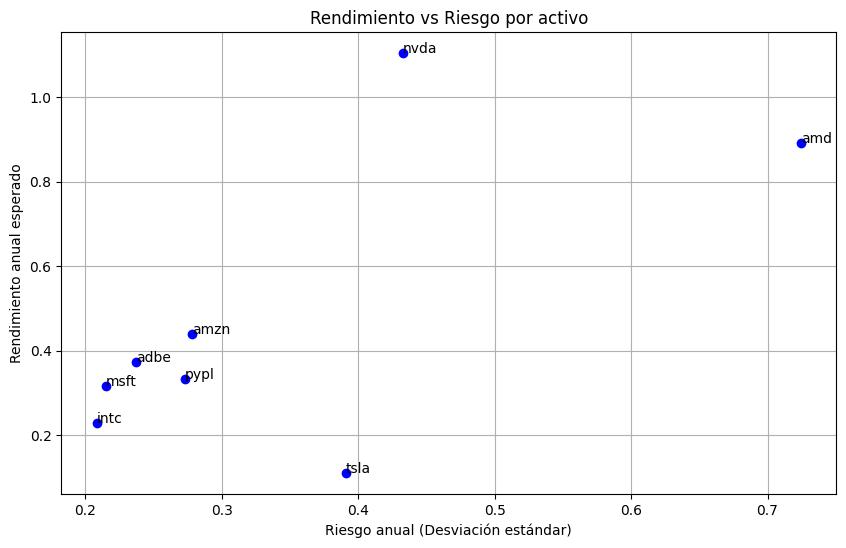

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(annual_risks, annual_returns, c='blue')
for i, symbol in enumerate(annual_returns.index):
    plt.annotate(symbol, (annual_risks[i], annual_returns[i]))
plt.xlabel("Riesgo anual (Desviación estándar)")
plt.ylabel("Rendimiento anual esperado")
plt.title("Rendimiento vs Riesgo por activo")
plt.grid(True)
plt.show()

**Maximizar rendimiento esperado**

$$
max \; R(w) = \sum_{i=1}^n w_i\mu_i
$$
donde
- $\mu_i$ rendimiento anual esperado del activo $i$
- $w_i$ es la proporcion del activo $i$

**Minimizar Riesgo**
$$
min \; \sigma(w) = \sum_{i=1}^n \sqrt{w^T\Sigma \, w}
$$
donde
- $\Sigma$ es la matriz de covarianza entre los rendimientos de los activos

**Restricciones**
- Suma de pesos igual a 1
$$
\sum_{i=1}^n w_i = 1
$$

- No short-selling (sin ventas en corto, si se desea):
$$
w_i \geq 0 \; \text{ para todo } i
$$

           amd      amzn      nvda      tsla      pypl      intc      adbe  \
amd   0.524977  0.027833  0.108144  0.066256  0.030085  0.039328  0.035295   
amzn  0.027833  0.077258  0.030934  0.037320  0.027836  0.021961  0.028709   
nvda  0.108144  0.030934  0.187231  0.045858  0.029938  0.034138  0.035330   
tsla  0.066256  0.037320  0.045858  0.152685  0.030953  0.020110  0.032900   
pypl  0.030085  0.027836  0.029938  0.030953  0.074646  0.023138  0.028222   
intc  0.039328  0.021961  0.034138  0.020110  0.023138  0.043342  0.021850   
adbe  0.035295  0.028709  0.035330  0.032900  0.028222  0.021850  0.056336   
msft  0.020129  0.033642  0.033410  0.024697  0.027813  0.026553  0.029244   

          msft  
amd   0.020129  
amzn  0.033642  
nvda  0.033410  
tsla  0.024697  
pypl  0.027813  
intc  0.026553  
adbe  0.029244  
msft  0.046133  


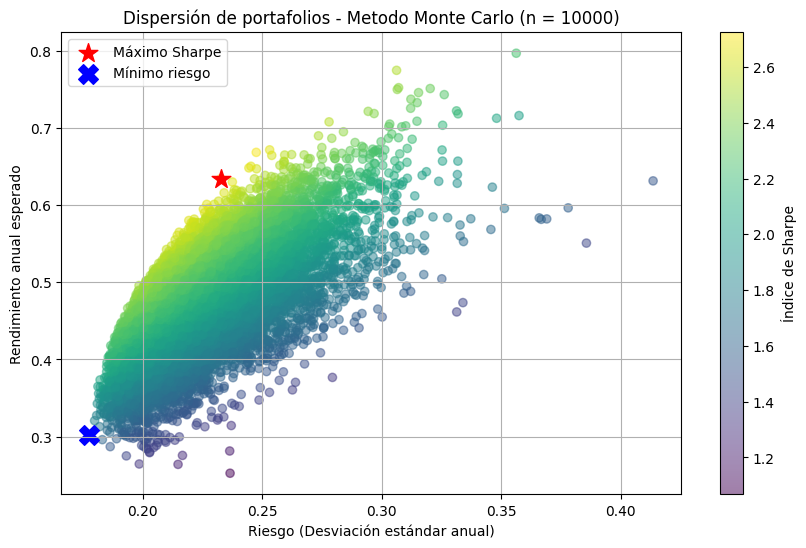

amd: 3.47%
amzn: 25.24%
nvda: 32.15%
tsla: 0.14%
pypl: 11.22%
intc: 1.36%
adbe: 22.51%
msft: 3.92%
Índice de Sharpe máximo: 2.7247


In [ ]:
# Monte Carlo
num_portfolios = 10000

annual_returns = returns.mean() * 252
annual_risks = returns.std() * np.sqrt(252)
cov_matrix = returns.cov() * 252

print(cov_matrix)
results = {'ret': [], 'risk': [], 'sharpe': [], 'weights': []}

for _ in range(num_portfolios):
    weights = np.random.random(len(symbols))
    weights /= np.sum(weights)

    port_return = np.dot(weights, annual_returns)
    port_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = port_return / port_risk  # Sin tasa libre de riesgo

    results['ret'].append(port_return)
    results['risk'].append(port_risk)
    results['sharpe'].append(sharpe_ratio)
    results['weights'].append(weights)

# Convertimos a arrays
returns_arr = np.array(results['ret'])
risks_arr = np.array(results['risk'])
sharpes_arr = np.array(results['sharpe'])

# Índices de portafolios clave
max_sharpe_idx = sharpes_arr.argmax()
min_risk_idx = risks_arr.argmin()

# Graficamos
plt.figure(figsize=(10, 6))
plt.scatter(risks_arr, returns_arr, c=sharpes_arr, cmap='viridis', alpha=0.5)
plt.colorbar(label='Índice de Sharpe')
plt.xlabel('Riesgo (Desviación estándar anual)')
plt.ylabel('Rendimiento anual esperado')
plt.title('Dispersión de portafolios - Metodo Monte Carlo (n = 10000)')

# Punto Sharpe máximo
plt.scatter(risks_arr[max_sharpe_idx], returns_arr[max_sharpe_idx],
            marker='*', color='red', s=200, label='Máximo Sharpe')

# Punto de menor riesgo
plt.scatter(risks_arr[min_risk_idx], returns_arr[min_risk_idx],
            marker='X', color='blue', s=200, label='Mínimo riesgo')

plt.legend()
plt.grid(True)
plt.show()

optimal_weights = results['weights'][max_sharpe_idx]
for symbol, weight in zip(symbols, optimal_weights):
    print(f"{symbol}: {weight:.2%}")

max_sharpe_value = sharpes_arr[max_sharpe_idx]
print(f"Índice de Sharpe máximo: {max_sharpe_value:.4f}")

In [ ]:
returns = np.array([0.892037, 0.439972, 1.104205, 0.110369, 0.334007, 0.230357, 0.373887, 0.316870])
cov_matrix = np.array([
    [0.524977, 0.027833, 0.108144, 0.066256, 0.030085, 0.039328, 0.035295, 0.020129],
    [0.027833, 0.077258, 0.030934, 0.037320, 0.027836, 0.021961, 0.028709, 0.033642],
    [0.108144, 0.030934, 0.187231, 0.045858, 0.029938, 0.034138, 0.035330, 0.033410],
    [0.066256, 0.037320, 0.045858, 0.152685, 0.030953, 0.020110, 0.032900, 0.024697],
    [0.030085, 0.027836, 0.029938, 0.030953, 0.074646, 0.023138, 0.028222, 0.027813],
    [0.039328, 0.021961, 0.034138, 0.020110, 0.023138, 0.043342, 0.021850, 0.026553],
    [0.035295, 0.028709, 0.035330, 0.032900, 0.028222, 0.021850, 0.056336, 0.029244],
    [0.020129, 0.033642, 0.033410, 0.024697, 0.027813, 0.026553, 0.029244, 0.036500],
])

<ipython-input-25-49abac61d2b0>:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  risk = float(res.F)


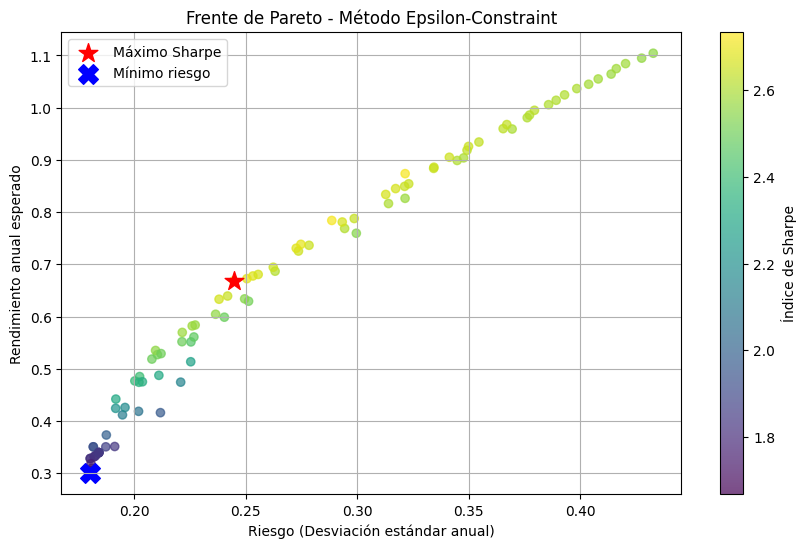

amd: 0.61%
amzn: 21.81%
nvda: 40.14%
tsla: 0.16%
pypl: 5.36%
intc: 2.48%
adbe: 11.82%
msft: 17.62%

Índice de Sharpe máximo: 2.7332


In [ ]:
symbols = ["amd", "amzn", "nvda", "tsla", "pypl", "intc", "adbe", "msft"]
# clase del problema pymoo
class PortfolioOptimization(ElementwiseProblem):
    def __init__(self, epsilon_return):
        n_assets = len(returns)
        super().__init__(n_var=n_assets, n_obj=1, n_ieq_constr=1, n_eq_constr=1, xl=0.0, xu=1.0)
        self.epsilon_return = epsilon_return

    def _evaluate(self, x, out, *args, **kwargs):
        x_norm = x / np.sum(x)
        risk = np.dot(x_norm.T, np.dot(cov_matrix, x_norm))
        expected_return = np.dot(x_norm, returns)

        out["F"] = risk
        out["G"] = [self.epsilon_return - expected_return]  # ε - retorno ≤ 0
        out["H"] = np.sum(x) - 1

# Parametrización del algoritmo
algorithm = DE(pop_size=100)
termination = get_termination("n_gen", 200)

# Barrido sobre distintos valores de epsilon (retorno mínimo)
epsilons = np.linspace(min(returns), max(returns), 100)

risks_arr = []
returns_arr = []
weights_arr = []

for eps in epsilons:
    problem = PortfolioOptimization(epsilon_return=eps)

    res = minimize(problem,
                   algorithm,
                   termination,
                   seed=42,
                   verbose=False)

    if res.F is not None:
        weights = res.X / np.sum(res.X)
        risk = float(res.F)
        expected_return = float(np.dot(weights, returns))

        risks_arr.append(np.sqrt(risk))  # desviación estándar
        returns_arr.append(expected_return)
        weights_arr.append(weights)

# Convertimos a arrays
risks_arr = np.array(risks_arr)
returns_arr = np.array(returns_arr)
weights_arr = np.array(weights_arr)

# Encontrar índice del Sharpe máximo (asumimos rf = 0)
sharpes_arr = returns_arr / risks_arr
max_sharpe_idx = np.argmax(sharpes_arr)
min_risk_idx = np.argmin(risks_arr)

# Gráfica
plt.figure(figsize=(10, 6))
plt.scatter(risks_arr, returns_arr, c=sharpes_arr, cmap='viridis', alpha=0.7)
plt.colorbar(label='Índice de Sharpe')
plt.xlabel('Riesgo (Desviación estándar anual)')
plt.ylabel('Rendimiento anual esperado')
plt.title('Frente de Pareto - Método Epsilon-Constraint')

# Punto Sharpe máximo
plt.scatter(risks_arr[max_sharpe_idx], returns_arr[max_sharpe_idx],
            marker='*', color='red', s=200, label='Máximo Sharpe')

# Punto de menor riesgo
plt.scatter(risks_arr[min_risk_idx], returns_arr[min_risk_idx],
            marker='X', color='blue', s=200, label='Mínimo riesgo')

plt.legend()
plt.grid(True)
plt.show()

# Mostrar pesos óptimos del máximo Sharpe
optimal_weights = weights_arr[max_sharpe_idx]
for symbol, weight in zip(symbols, optimal_weights):
    print(f"{symbol}: {weight:.2%}")

print(f"\nÍndice de Sharpe máximo: {sharpes_arr[max_sharpe_idx]:.4f}")

returns1 = returns_arr
risks1 = risks_arr
sharpes1 = sharpes_arr
weights1 = weights_arr

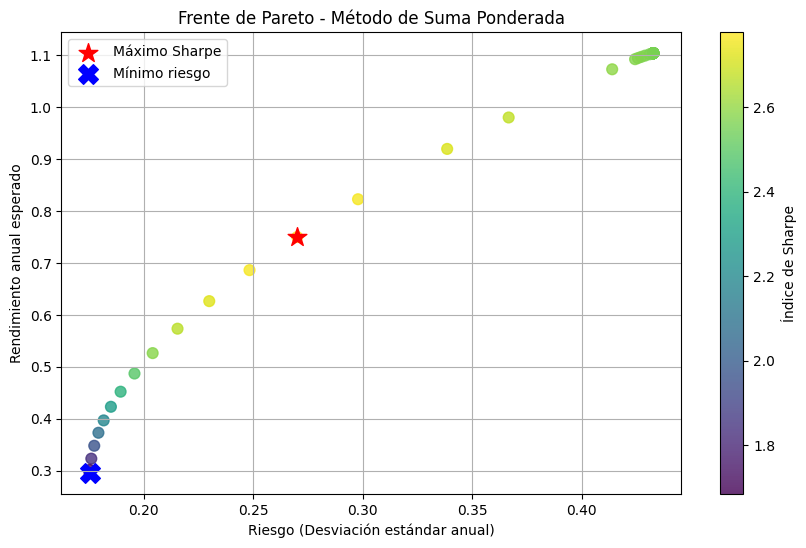

Portafolio con mayor índice de Sharpe:
amd: 4.05%
amzn: 26.91%
nvda: 46.61%
tsla: 0.00%
pypl: 7.43%
intc: 0.00%
adbe: 15.00%
msft: 0.00%
Índice de Sharpe: 2.7773


In [ ]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

def weighted_sum_objective(weights, returns, cov_matrix, lambda_):
    risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    expected_return = np.dot(weights, returns)
    return lambda_ * risk - (1 - lambda_) * expected_return

n_assets = len(returns)

# Restricción: suma de pesos = 1
constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

# Límite de cada peso: entre 0 y 1
bounds = tuple((0, 1) for _ in range(n_assets))

# Valor inicial: pesos uniformes
x0 = np.array([1.0 / n_assets] * n_assets)

lambdas = np.linspace(0, 1, 50)

risks_ws = []
returns_ws = []
solutions_ws = []

for lambda_ in lambdas:
    res = minimize(weighted_sum_objective,
                   x0=x0,
                   args=(returns, cov_matrix, lambda_),
                   method='SLSQP',
                   bounds=bounds,
                   constraints=constraints)

    if res.success:
        w = res.x
        risk = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))
        ret = np.dot(w, returns)

        risks_ws.append(risk)
        returns_ws.append(ret)
        solutions_ws.append(w)
    else:
        print(f"Falló la optimización para lambda = {lambda_:.2f}")

sharpes = [r / s for r, s in zip(returns_ws, risks_ws)]

sharpes = [r / s for r, s in zip(returns_ws, risks_ws)]
max_sharpe_idx = np.argmax(sharpes)
min_risk_idx = np.argmin(risks_ws)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(risks_ws, returns_ws, c=sharpes, cmap='viridis', s=60, alpha=0.8)
plt.colorbar(scatter, label='Índice de Sharpe')

plt.xlabel('Riesgo (Desviación estándar anual)')
plt.ylabel('Rendimiento anual esperado')
plt.title('Frente de Pareto - Método de Suma Ponderada')
plt.grid(True)

# Máximo Sharpe
plt.scatter(risks_ws[max_sharpe_idx], returns_ws[max_sharpe_idx],
            marker='*', color='red', s=200, label='Máximo Sharpe')

# Mínimo riesgo
plt.scatter(risks_ws[min_risk_idx], returns_ws[min_risk_idx],
            marker='X', color='blue', s=200, label='Mínimo riesgo')

plt.legend()
plt.show()

sharpes = [r / s for r, s in zip(returns_ws, risks_ws)]
max_idx = np.argmax(sharpes)

print("Portafolio con mayor índice de Sharpe:")
for symbol, weight in zip(symbols, solutions_ws[max_idx]):
    print(f"{symbol}: {weight:.2%}")
print(f"Índice de Sharpe: {sharpes[max_idx]:.4f}")

returns2 = returns_ws
risks2 = risks_ws
sharpes2 = sharpes
weights2 = solutions_ws

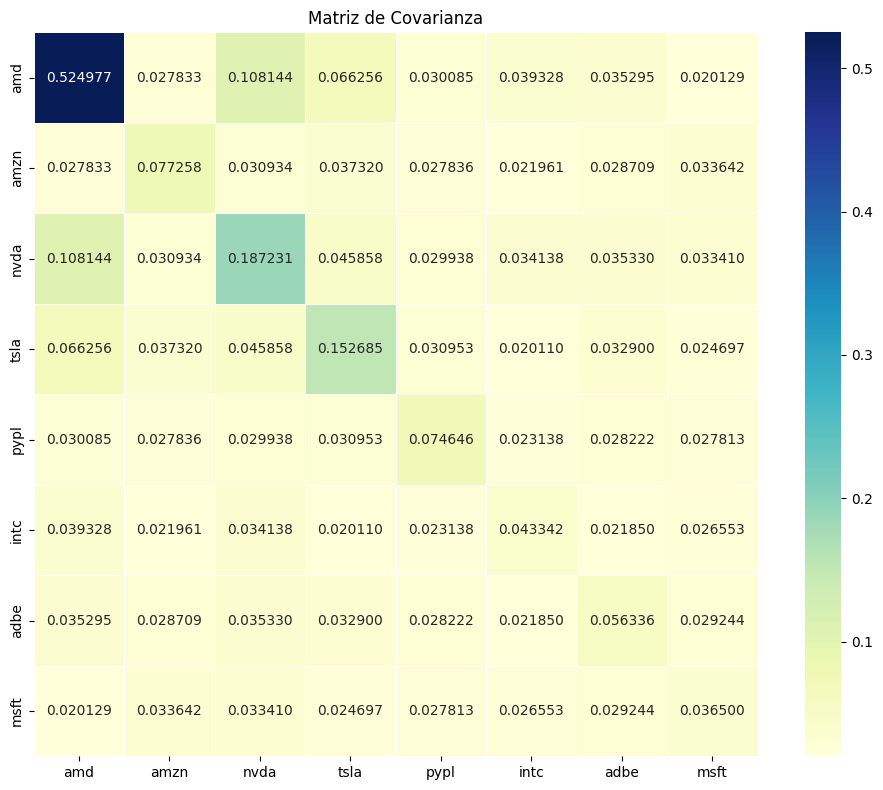

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cov_matrix = np.array([
    [0.524977, 0.027833, 0.108144, 0.066256, 0.030085, 0.039328, 0.035295, 0.020129],
    [0.027833, 0.077258, 0.030934, 0.037320, 0.027836, 0.021961, 0.028709, 0.033642],
    [0.108144, 0.030934, 0.187231, 0.045858, 0.029938, 0.034138, 0.035330, 0.033410],
    [0.066256, 0.037320, 0.045858, 0.152685, 0.030953, 0.020110, 0.032900, 0.024697],
    [0.030085, 0.027836, 0.029938, 0.030953, 0.074646, 0.023138, 0.028222, 0.027813],
    [0.039328, 0.021961, 0.034138, 0.020110, 0.023138, 0.043342, 0.021850, 0.026553],
    [0.035295, 0.028709, 0.035330, 0.032900, 0.028222, 0.021850, 0.056336, 0.029244],
    [0.020129, 0.033642, 0.033410, 0.024697, 0.027813, 0.026553, 0.029244, 0.036500],
])

symbols = ['amd', 'amzn', 'nvda', 'tsla', 'pypl', 'intc', 'adbe', 'msft']
cov_df = pd.DataFrame(cov_matrix, index=symbols, columns=symbols)

plt.figure(figsize=(10, 8))
sns.heatmap(cov_df, annot=True, fmt=".6f", cmap="YlGnBu", linewidths=0.5, square=True)
plt.title("Matriz de Covarianza")
plt.tight_layout()
plt.show()